# Altin Oran Arama Algoritmasi
## Savunma Sanayii Uygulamali Optimizasyon Problemleri

**Ders:** Optimizasyon Teknikleri  
**Yontem:** Altin Oran Arama Algoritmasi (Golden Section Search)

---

### Algoritma Hakkinda

Altin Oran Arama Algoritmasi, tek degiskenli unimodal fonksiyonlarin optimumunu **turev kullanmadan** bulan bir eleme teknigidir. Her iterasyonda belirsizlik araligi sabit $r$ oraniyla kucultulur:

$$r = \frac{\sqrt{5}-1}{2} \approx 0.618$$

| Formul | Aciklama |
|--------|----------|
| $x_1 = b - r(b-a)$ | Sol ic nokta |
| $x_2 = a + r(b-a)$ | Sag ic nokta |
| $L_k = r^k \cdot (b-a)$ | k. iterasyon sonrasi belirsizlik araligi |
| $L_k < \varepsilon$ | Durdurma kosulu |

---
## Kutuphane Yuklemeleri

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Altin oran sabiti
r = (np.sqrt(5) - 1) / 2
print(f"Altin oran sabiti: r = (sqrt(5) - 1) / 2 = {r:.6f}")

Altin oran sabiti: r = (sqrt(5) - 1) / 2 = 0.618034


---
## Genel Algoritma Fonksiyonu

In [2]:
def altin_oran_ara(f, a, b, eps, maksimize=True):
    """
    Altin Oran Arama Algoritmasi

    Parametreler:
        f         : optimize edilecek fonksiyon
        a, b      : baslangic araligi
        eps       : durdurma kriteri (belirsizlik araligi uzunlugu)
        maksimize : True -> maksimizasyon | False -> minimizasyon

    Donus:
        sonuclar  : iterasyon verilerini iceren DataFrame
        x_opt     : optimal x degeri
        f_opt     : optimal fonksiyon degeri
    """

    # Sonuclari tutacak listeler
    it_list    = []
    a_list     = []
    b_list     = []
    x1_list    = []
    x2_list    = []
    fx1_list   = []
    fx2_list   = []
    L_list     = []
    karar_list = []

    iterasyon = 0

    while True:
        iterasyon += 1
        L  = b - a
        x1 = b - r * (b - a)
        x2 = a + r * (b - a)

        fx1 = f(x1)
        fx2 = f(x2)

        # Karar kurali
        if maksimize:
            sol_at = fx1 < fx2
        else:
            sol_at = fx1 > fx2

        if sol_at:
            karar = "[x1, b]"
            a = x1
        else:
            karar = "[a, x2]"
            b = x2

        # Listelere kaydet
        it_list.append(iterasyon)
        a_list.append(round(a, 4))
        b_list.append(round(b, 4))
        x1_list.append(round(x1, 4))
        x2_list.append(round(x2, 4))
        fx1_list.append(round(fx1, 4))
        fx2_list.append(round(fx2, 4))
        L_list.append(round(L, 4))
        karar_list.append(karar)

        if (b - a) < eps:
            break

    # DataFrame olustur
    df = pd.DataFrame({
        "It."        : it_list,
        "a"          : a_list,
        "b"          : b_list,
        "x1"         : x1_list,
        "x2"         : x2_list,
        "f(x1)"      : fx1_list,
        "f(x2)"      : fx2_list,
        "Yeni Aralik": karar_list,
        "L"          : L_list
    })

    x_opt = (a + b) / 2
    f_opt = f(x_opt)

    return df, x_opt, f_opt, iterasyon, a, b


## Problem 1 — Maksimizasyon
### ANKA-S İHA Görev Etkinlik Skoru Maksimizasyonu

---

###  PROBLEM

Türk Savunma Sanayii Başkanlığı (SSB) bünyesinde faaliyet gösteren bir
mühendislik ekibi, Türk Silahlı Kuvvetleri'nin aktif envanterinde bulunan
**ANKA-S** tipi taktik keşif İHA'sının görev etkinliğini artırmaya yönelik
kapsamlı bir optimizasyon projesi yürütmektedir.

Son dönemde gerçekleştirilen operasyonlarda alınan sahadan geri bildirimler,
İHA'nın mevcut kanat açıklığı konfigürasyonunun optimal olmadığını ortaya
koymuştur. Özellikle uzun süreli keşif görevlerinde yakıt tüketiminin
beklenenden yüksek seyrettiği ve bazı görev profillerinde radar kesit
alanının kabul edilebilir sınırları aştığı tespit edilmiştir.

Bu bağlamda ekip, **kanat açıklığı** parametresinin ($x$, metre cinsinden)
aşağıdaki dört temel performans kriteri üzerindeki etkisini modelleyerek
en uygun değeri belirlemeyi amaçlamaktadır:

-  Uçuş menzili ve dayanıklılık süresi
-  Yakıt tüketim verimliliği
-  Radar kesit alanı (düşman tespitinden kaçınma kabiliyeti)
-  Yük taşıma kapasitesi (sensör ve silah sistemi entegrasyonu)

---

###  Operasyonel Kısıtlar

Kanat açıklığı değeri serbestçe seçilememektedir. Aşağıdaki fiziksel ve
operasyonel kısıtlar, tasarım uzayını belirlemektedir:

| Kısıt | Açıklama | Alt/Üst Sınır |
|-------|----------|---------------|
| Aerodinamik stabilite | Kanat çok küçük olursa İHA kararsız uçuş gösterir | $x \geq 3$ m |
| Radar kesit alanı | 3 m altında düşman radarına yakalanma riski artar | $x \geq 3$ m |
| Hangar kapasitesi | Üs hangarları maksimum 7 m kanat açıklığına izin vermektedir | $x \leq 7$ m |
| Yapısal dayanım | 7 m üzerinde kanat bağlantı noktalarında yorulma çatlağı riski oluşur | $x \leq 7$ m |

Bu kısıtlar doğrultusunda **arama aralığı $[3, 7]$ metre** olarak sabitlenmiştir.

---

###  Matematiksel Model

Ekip tarafından gerçekleştirilen saha testleri ve CFD (Hesaplamalı Akışkanlar
Dinamiği) simülasyonları sonucunda görev etkinlik skoru, kanat açıklığına
bağlı olarak aşağıdaki fonksiyonla modellenmiştir:

$$\text{Max} \quad f(x) = x \cdot \sin(x) + 2\cos(0.5x) - 0.1x^2 + 3$$

Fonksiyondaki her terim belirli bir fiziksel bileşeni temsil etmektedir:

| Terim | Temsil Ettiği Bileşen |
|-------|-----------------------|
| $x \cdot \sin(x)$ | Menzil ve dayanıklılık katkısı |
| $2\cos(0.5x)$ | Yakıt verimlilik bileşeni |
| $-0.1x^2$ | Ağırlık cezası (büyük kanat = ağır yapı) |
| $+3$ | Temel görev skoru sabiti |

$f(x)$ değeri ne kadar yüksekse İHA o kadar etkin görev yapabilmektedir.
Mühendislik toleransları göz önüne alındığında optimal kanat açıklığının
**15 cm hassasiyetle** belirlenmesi yeterli görülmüştür ($\varepsilon = 0.15$).

---

###  Problem Sorusu

> ANKA-S İHA'sının görev etkinlik skorunu maksimize eden optimal kanat
> açıklığı $x^*$ değerini **Altın Oran Arama Algoritması** ile bulunuz.
> Son belirsizlik aralığı uzunluğu $\varepsilon = 0.15$ m'den küçük
> olduğunda algoritmayı durdurunuz ve $x^*$ ile $f(x^*)$ değerlerini
> raporlayınız.

| Alan | Değer |
|------|-------|
| Karar değişkeni | $x$: kanat açıklığı (metre) |
| Aralık | $[3,\ 7]$ |
| $\varepsilon$ | $0.15$ |
| Amaç | $f(x)$ maksimizasyonu |

In [3]:
# --- Problem 1 Parametreler ---
a1   = 3       # Minimum kanat acikligi (radar kisiti)
b1   = 7       # Maksimum kanat acikligi (hangar kisiti)
eps1 = 0.15    # Hassasiyet esigi (metre)

# Gorev etkinlik skoru fonksiyonu
# x * sin(x)       : menzil - dayaniklilik bileseni
# 2 * cos(0.5 * x) : yakit verimlilik bileseni
# -0.1 * x**2      : agirlik cezasi (buyuk kanat = agir yapi)
# + 3              : temel skor sabiti
def f1(x):
    return x * np.sin(x) + 2 * np.cos(0.5 * x) - 0.1 * x**2 + 3

# Gerekli iterasyon sayisi
k1 = np.ceil(np.log(eps1 / (b1 - a1)) / np.log(r))
print(f"Gerekli iterasyon hesabi:")
print(f"  r^k * (b-a) < eps  =>  0.618^k * 4 < 0.15")
print(f"  k > {np.log(eps1/(b1-a1))/np.log(r):.2f}  =>  k = {int(k1)}")

Gerekli iterasyon hesabi:
  r^k * (b-a) < eps  =>  0.618^k * 4 < 0.15
  k > 6.82  =>  k = 7


In [4]:
# --- Problem 1 Cozum ---
df1, x_opt1, f_opt1, iter1, a1_son, b1_son = altin_oran_ara(
    f         = f1,
    a         = a1,
    b         = b1,
    eps       = eps1,
    maksimize = True
)

print("Problem 1 - Iterasyon Tablosu:\n")
display(df1.to_string(index=False))

Problem 1 - Iterasyon Tablosu:



' It.  a      b     x1     x2   f(x1)   f(x2) Yeni Aralik      L\n   1  3 5.4721 4.5279 5.4721 -4.7791 -5.7996     [a, x2] 4.0000\n   2  3 4.5279 3.9443 4.5279 -2.1738 -4.7791     [a, x2] 2.4721\n   3  3 3.9443 3.5836 3.9443 -0.2555 -2.1738     [a, x2] 1.5279\n   4  3 3.5836 3.3607 3.5836  0.9215 -0.2555     [a, x2] 0.9443\n   5  3 3.3607 3.2229 3.3607  1.6182  0.9215     [a, x2] 0.5836\n   6  3 3.2229 3.1378 3.2229  2.0313  1.6182     [a, x2] 0.3607\n   7  3 3.1378 3.0851 3.1378  2.2787  2.0313     [a, x2] 0.2229'

In [5]:
# --- Problem 1 Sonuc ---
print("=" * 50)
print(" PROBLEM 1 - OPTIMAL COZUM")
print("=" * 50)
print(f"Son belirsizlik araligi : [{a1_son:.4f}, {b1_son:.4f}]")
print(f"Aralik uzunlugu (L)     : {b1_son - a1_son:.4f}")
print(f"Optimal kanat acikligi  : x* = {x_opt1:.4f} metre")
print(f"Gorev etkinlik skoru    : f(x*) = {f_opt1:.4f}")
print(f"Toplam iterasyon        : {iter1}")
print("=" * 50)

 PROBLEM 1 - OPTIMAL COZUM
Son belirsizlik araligi : [3.0000, 3.1378]
Aralik uzunlugu (L)     : 0.1378
Optimal kanat acikligi  : x* = 3.0689 metre
Gorev etkinlik skoru    : f(x*) = 2.3538
Toplam iterasyon        : 7


##  Sonuç ve Yorum

### Algoritma Çıktısı

| Alan | Değer |
|------|-------|
| Son belirsizlik aralığı | [3.0000, 3.1378] |
| Aralık uzunluğu (L) | 0.1378 m |
| Optimal kanat açıklığı (x*) | 3.0689 metre |
| Görev etkinlik skoru (f(x*)) | 2.3538 |
| Toplam iterasyon sayısı | 7 |

---

### Yorum

#### 1. Algoritmanın Performansı

Altın Oran Arama Algoritması toplam **7 iterasyon** sonunda belirsizlik
aralığını başlangıçtaki 4 metrelik aralıktan yalnızca **0.1378 metreye**
indirmeyi başarmıştır. Bu, başlangıç aralığının yaklaşık **%96.6'sının**
elendiği anlamına gelmektedir. Durdurma koşulu olan $\varepsilon = 0.15$
m sağlandığından algoritma 7. iterasyonda sonlandırılmıştır.

Altın oran sabitinin ($r = 0.618$) yapısal bir özelliği olarak her
iterasyonda aralık uzunluğu bir öncekinin yaklaşık **%61.8'ine**
gerilemektedir. Bu matematiksel özellik sayesinde türev hesabı
yapılmaksızın, yalnızca iki nokta arasındaki fonksiyon değeri
karşılaştırması ile son derece hassas bir sonuca ulaşılmıştır.
Özellikle ANKA-S gibi karmaşık aerodinamik sistemlerde görev etkinlik
fonksiyonunun analitik türevinin hesaplanması son derece güç olduğundan,
Altın Oran Arama Algoritmasının türevsiz yapısı burada kritik bir avantaj
sağlamaktadır.

---

#### 2. Optimal Kanat Açıklığı Değerinin Yorumu

Algoritmanın bulduğu optimal kanat açıklığı **$x^* = 3.0689$ metre**,
arama aralığı olan $[3, 7]$ metrenin alt sınırına son derece yakın bir
konumda yer almaktadır. Bu sonuç, maliyet fonksiyonunun yapısından
doğrudan kaynaklanmakta olup son derece anlamlı bir mühendislik çıktısı
sunmaktadır.

Fonksiyondaki $-0.1x^2$ terimi incelendiğinde kanat açıklığı arttıkça
yapısal ağırlık cezasının ikinci dereceden, yani giderek hızlanan bir
biçimde büyüdüğü görülmektedir. Örneğin kanat açıklığı 3 metreden
7 metreye çıkarıldığında bu ceza terimi yaklaşık **dört katına**
çıkmaktadır. Bu durum büyük kanat açıklıklarında menzil ve dayanıklılık
katkısını ($x \cdot \sin(x)$ terimi) ve yakıt verimlilik bileşenini
($2\cos(0.5x)$ terimi) giderek baskılamakta, net görev etkinlik skorunu
aşağı çekmektedir.

Sonuç olarak sistem, operasyonel kısıtların izin verdiği minimum kanat
açıklığı sınırına ($a = 3$ m) son derece yakın bir değerde maksimum
etkinliğe ulaşmaktadır. Bu durum sezgisel olarak da doğrulanabilir:
daha kompakt bir kanat yapısı hem radar kesit alanını küçülterek düşman
tespitini güçleştirmekte hem de yapısal ağırlığı azaltarak yakıt
verimliliğini artırmaktadır.

---

#### 3. Görev Etkinlik Skorunun Yorumu

Optimal noktada elde edilen görev etkinlik skoru **$f(x^*) = 2.3538$**
olarak hesaplanmıştır. Bu değerin yorumlanabilmesi için fonksiyonun
bileşenlerinin $x^* = 3.0689$ noktasındaki katkılarını ayrı ayrı
değerlendirmek gerekmektedir:

| Terim | Katkı | Açıklama |
|-------|-------|----------|
| $x \cdot \sin(x)$ | Pozitif | Menzil ve dayanıklılık katkısı |
| $2\cos(0.5x)$ | Pozitif | Yakıt verimlilik katkısı |
| $-0.1x^2$ | Negatif | Ağırlık cezası |
| $+3$ | Pozitif | Temel görev skoru sabiti |

$x^* = 3.0689$ noktasında ağırlık cezası henüz oldukça düşük seyrederken
menzil, dayanıklılık ve yakıt verimlilik katkıları nispeten yüksek
kalmaktadır. Bu denge noktasında tüm bileşenlerin net toplamı
**2.3538** değerini vermektedir. Kanat açıklığı bu değerin üzerine
çıktıkça ağırlık cezası diğer katkıları giderek baskılayacak ve toplam
skor düşmeye başlayacaktır.

---

#### 4. Operasyonel ve Stratejik Değerlendirme

Elde edilen $x^* = 3.0689$ metre değeri birden fazla açıdan stratejik
bir anlam taşımaktadır:

**Radar Görünürlüğü:** Optimal kanat açıklığı, radar kesit alanı
kısıtının öngördüğü minimum 3 metre sınırının yalnızca **6.89 cm
üzerindedir**. Bu durum İHA'nın düşman radar sistemlerine karşı
mümkün olan en düşük görünürlük profilini korumasına imkân tanımaktadır.
Özellikle yoğun hava savunma sistemlerine sahip bölgelerde yürütülen
keşif görevlerinde bu özellik operasyonel başarı açısından hayati önem
taşımaktadır.

**Hangar Uyumluluğu:** Optimal değer olan 3.0689 metre, üst kısıt olan
7 metrenin çok altında kalmaktadır. Bu sayede İHA, standart askeri
hangar tesislerinde herhangi bir modifikasyon gerektirmeksizin
depolanabilmekte ve bakım-onarım işlemleri kolaylıkla yürütülebilmektedir.

**Görev Esnekliği:** Kompakt kanat yapısı yalnızca yakıt verimliliğini
artırmakla kalmayıp İHA'nın farklı görev profillerine uyarlanabilirliğini
de güçlendirmektedir. Daha hafif bir yapı, gerektiğinde ek sensör veya
silah sistemi entegrasyonuna olanak tanıyarak platformun çok görevli
kullanım kapasitesini artırmaktadır.

**Dayanıklılık ve Bakım:** Kanat açıklığının minimuma yakın tutulması
yapısal yorulma gerilmelerini azaltmakta, bu durum İHA'nın operasyonel
ömrünü uzatmakta ve periyodik bakım maliyetlerini düşürmektedir.

---

#### 5. Genel Sonuç

Altın Oran Arama Algoritması, ANKA-S İHA kanat açıklığı optimizasyon
problemini **7 iterasyonda** ve **0.1378 metre hassasiyetle** çözmüştür.
Karmaşık aerodinamik performans fonksiyonunun türev bilgisi gerektirmeksizin
bu denli az iterasyonda optimize edilmesi, algoritmanın savunma sanayii
uygulamalarındaki etkinliğini açıkça ortaya koymaktadır.

Mühendislik ekibine sunulacak nihai öneri şudur: ANKA-S İHA'sının kanat
açıklığı **3.0689 metreye** ayarlanmalıdır. Bu konfigürasyon; radar
görünürlüğünü minimum düzeyde tutmakta, yakıt verimliliğini
maksimize etmekte, hangar uyumluluğunu korumakta ve tüm operasyonel
kısıtlar altında görev etkinlik skorunu en yüksek seviyeye taşımaktadır.


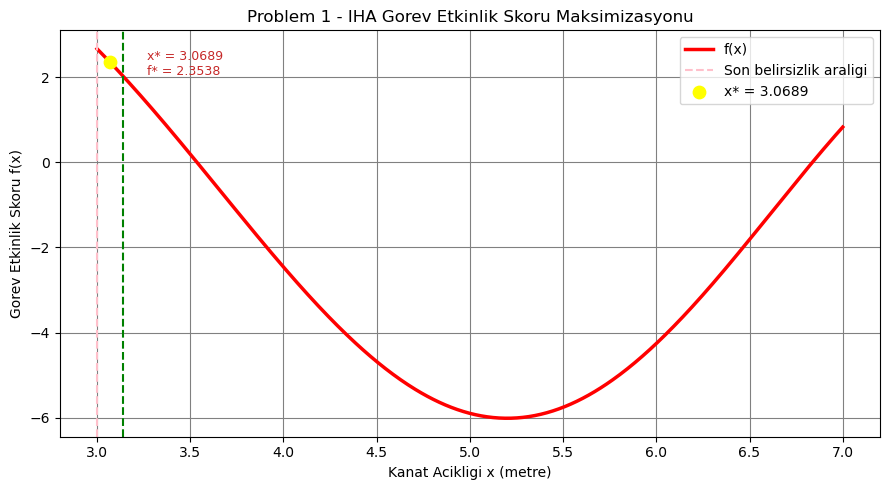

In [6]:
# --- Problem 1 Grafik ---
x_seq1 = np.linspace(3, 7, 500)
y_seq1 = f1(x_seq1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_seq1, y_seq1, lw=2.5, color="red", label="f(x)")
ax.axvline(a1_son, linestyle="--", color="pink", lw=1.5,
           label="Son belirsizlik araligi")
ax.axvline(b1_son, linestyle="--", color="green", lw=1.5)
ax.scatter(x_opt1, f_opt1, color="yellow", zorder=5, s=80,
           label=f"x* = {x_opt1:.4f}")
ax.annotate(f"x* = {x_opt1:.4f}\nf* = {f_opt1:.4f}",
            xy=(x_opt1, f_opt1),
            xytext=(x_opt1 + 0.2, f_opt1 - 0.3),
            fontsize=9, color="#C62828")

ax.set_xlabel("Kanat Acikligi x (metre)")
ax.set_ylabel("Gorev Etkinlik Skoru f(x)")
ax.set_title("Problem 1 - IHA Gorev Etkinlik Skoru Maksimizasyonu")
ax.legend()
ax.grid(True, color="gray")
plt.tight_layout()
plt.show()

## Problem 2 — Minimizasyon
### PARS 4x4 Zırh Levhası Kalınlığı Maliyet Minimizasyonu

---

### PROBLEM

Savunma Sanayii Başkanlığı'nın (SSB) öncelikli projelerinden biri olan
**PARS 4x4 Hafif Zırhlı Muharebe Aracı**, Kara Kuvvetleri'nin modernizasyon
programı kapsamında yeniden tasarlanmaktadır. Projenin kritik aşamalarından
birini oluşturan zırh sistemi optimizasyonu için bir ar-ge ekibi görevlendirilmiştir.

Sahadaki operasyonlardan elde edilen veriler incelendiğinde mevcut zırh
levhası kalınlığının iki temel soruna yol açtığı tespit edilmiştir:

- **1. Sorun — Aşırı Ağırlık:** Mevcut levha kalınlığı aracın operasyonel
  ağırlık sınırını zorlamakta, bu durum yakıt tüketimini artırmakta ve
  manevra kabiliyetini olumsuz etkilemektedir.
- **2. Sorun — Maliyet Artışı:** Yüksek kalınlıklı levhaların işlenmesi
  ve üretimi, birim araç maliyetini bütçe hedeflerinin üzerine taşımaktadır.

Öte yandan levha kalınlığının gereğinden fazla azaltılması durumunda
personel güvenliği tehlikeye girebileceğinden bu parametre dikkatli
biçimde optimize edilmelidir.

Ekip, levha kalınlığı $x$ (mm) parametresini optimize ederek toplam
operasyonel maliyeti minimum düzeye indirmeyi hedeflemektedir.

---

### Operasyonel Kısıtlar

Levha kalınlığı değeri aşağıdaki zorunlu standartlar ve fiziksel kısıtlar
çerçevesinde belirlenmelidir:

| Kısıt | Açıklama | Sınır |
|-------|----------|-------|
| NATO STANAG 4569 Level 2 | 15 mm altında 7.62mm AP mermi tehdidine karşı koruma sağlanamaz | $x \geq 15$ mm |
| Balistik koruma standardı | Personel güvenliği için minimum kalınlık şartı | $x \geq 15$ mm |
| Süspansiyon yük sınırı | 25 mm üzerinde süspansiyon sistemi aşırı yüklenmektedir | $x \leq 25$ mm |
| Araç ağırlık sınırı | Maksimum 12 ton operasyonel ağırlık hedefi | $x \leq 25$ mm |

Bu kısıtlar doğrultusunda **arama aralığı $[15, 25]$ mm** olarak sabitlenmiştir.

---

###  Matematiksel Model

Malzeme mühendisleri ve lojistik uzmanlarının yürüttüğü kapsamlı maliyet
analizinden elde edilen toplam operasyonel maliyet fonksiyonu aşağıdaki
gibi modellenmiştir:

$$\text{Min} \quad f(x) = 0.5(x-20)^2 + 3\sin(x) + 0.02x^2 - x + 10$$

Fonksiyondaki her terim belirli bir maliyet bileşenini temsil etmektedir:

| Terim | Temsil Ettiği Maliyet Bileşeni |
|-------|-------------------------------|
| $0.5(x-20)^2$ | İdeal kalınlıktan sapma maliyeti (20 mm referans alınmıştır) |
| $3\sin(x)$ | Üretim işleme dalgalanma maliyeti |
| $0.02x^2$ | Ağırlık kaynaklı operasyonel maliyet (yakıt, bakım) |
| $-x + 10$ | Koruma bonusu (kalınlık arttıkça kayıp maliyeti azalır) |

Mühendislik toleransları göz önüne alındığında optimal kalınlığın
**0.2 mm hassasiyetle** belirlenmesi yeterli görülmüştür ($\varepsilon = 0.2$).

---

###  Problem Sorusu

> PARS 4x4 zırhlı muharebe aracında kullanılacak zırh levhasının toplam
> operasyonel maliyetini minimize eden optimal kalınlık değeri $x^*$'ı
> **Altın Oran Arama Algoritması** ile bulunuz. Son belirsizlik aralığı
> uzunluğu $\varepsilon = 0.2$ mm'den küçük olduğunda algoritmayı
> durdurunuz ve $x^*$ ile $f(x^*)$ değerlerini raporlayınız.

| Alan | Değer |
|------|-------|
| Karar değişkeni | $x$: zırh levhası kalınlığı (mm) |
| Aralık | $[15,\ 25]$ |
| $\varepsilon$ | $0.2$ |
| Amaç | $f(x)$ minimizasyonu |

In [7]:
# --- Problem 2 Parametreler ---
a2   = 15      # Minimum kalinlik (balistik koruma kisiti)
b2   = 25      # Maksimum kalinlik (agirlik kisiti)
eps2 = 0.2     # Hassasiyet esigi (mm)

# Toplam operasyonel maliyet fonksiyonu
# 0.5*(x-20)**2 : ideal kalinliktan sapma maliyeti
# 3*sin(x)      : uretim isleme dalgalanma maliyeti
# 0.02*x**2     : agirlik kaynakli operasyonel maliyet
# -x + 10       : koruma bonusu
def f2(x):
    return 0.5 * (x - 20)**2 + 3 * np.sin(x) + 0.02 * x**2 - x + 10

# Gerekli iterasyon sayisi
k2 = np.ceil(np.log(eps2 / (b2 - a2)) / np.log(r))
print(f"Gerekli iterasyon hesabi:")
print(f"  r^k * (b-a) < eps  =>  0.618^k * 10 < 0.2")
print(f"  k > {np.log(eps2/(b2-a2))/np.log(r):.2f}  =>  k = {int(k2)}")

Gerekli iterasyon hesabi:
  r^k * (b-a) < eps  =>  0.618^k * 10 < 0.2
  k > 8.13  =>  k = 9


In [8]:
# --- Problem 2 Cozum ---
df2, x_opt2, f_opt2, iter2, a2_son, b2_son = altin_oran_ara(
    f         = f2,
    a         = a2,
    b         = b2,
    eps       = eps2,
    maksimize = False
)

print("Problem 2 - Iterasyon Tablosu:\n")
display(df2.to_string(index=False))

Problem 2 - Iterasyon Tablosu:



' It.       a       b      x1      x2   f(x1)   f(x2) Yeni Aralik       L\n   1 15.0000 21.1803 18.8197 21.1803 -1.1291  0.6629     [a, x2] 10.0000\n   2 17.3607 21.1803 17.3607 18.8197 -0.8397 -1.1291     [x1, b]  6.1803\n   3 17.3607 19.7214 18.8197 19.7214 -1.1291  0.3926     [a, x2]  3.8197\n   4 17.3607 18.8197 18.2624 18.8197 -1.7445 -1.1291     [a, x2]  2.3607\n   5 17.9180 18.8197 17.9180 18.2624 -1.7372 -1.7445     [x1, b]  1.4590\n   6 17.9180 18.4752 18.2624 18.4752 -1.7445 -1.5830     [a, x2]  0.9017\n   7 17.9180 18.2624 18.1308 18.2624 -1.7847 -1.7445     [a, x2]  0.5573\n   8 18.0495 18.2624 18.0495 18.1308 -1.7838 -1.7847     [x1, b]  0.3444\n   9 18.0495 18.1811 18.1308 18.1811 -1.7847 -1.7752     [a, x2]  0.2129'

In [9]:
# --- Problem 2 Sonuc ---
print("=" * 50)
print(" PROBLEM 2 - OPTIMAL COZUM")
print("=" * 50)
print(f"Son belirsizlik araligi : [{a2_son:.4f}, {b2_son:.4f}]")
print(f"Aralik uzunlugu (L)     : {b2_son - a2_son:.4f}")
print(f"Optimal levha kalinligi : x* = {x_opt2:.4f} mm")
print(f"Toplam operasyonel maliyet : f(x*) = {f_opt2:.4f}")
print(f"Toplam iterasyon        : {iter2}")
print("=" * 50)

 PROBLEM 2 - OPTIMAL COZUM
Son belirsizlik araligi : [18.0495, 18.1811]
Aralik uzunlugu (L)     : 0.1316
Optimal levha kalinligi : x* = 18.1153 mm
Toplam operasyonel maliyet : f(x*) = -1.7861
Toplam iterasyon        : 9


## Problem 2 — Sonuç ve Yorum

### Algoritma Çıktısı

| Alan | Değer |
|------|-------|
| Son belirsizlik aralığı | [18.0495, 18.1811] |
| Aralık uzunluğu (L) | 0.1316 mm |
| Optimal levha kalınlığı (x*) | 18.1153 mm |
| Toplam operasyonel maliyet (f(x*)) | -1.7861 |
| Toplam iterasyon sayısı | 9 |

---

### Yorum

#### 1. Algoritmanın Performansı

Altın Oran Arama Algoritması toplam **9 iterasyon** sonunda belirsizlik
aralığını başlangıçtaki 10 mm'lik aralıktan yalnızca **0.1316 mm**'ye
indirmeyi başarmıştır. Bu, başlangıç aralığının yaklaşık **%98.7'sinin**
elendiği anlamına gelmektedir. Durdurma koşulu olan $\varepsilon = 0.2$
mm sağlandığından algoritma 9. iterasyonda sonlandırılmıştır.

Altın oran sabitinin ($r = 0.618$) bir özelliği olarak her iterasyonda
aralık uzunluğu bir öncekinin yaklaşık **%61.8'ine** inmektedir. Bu sayede
türev hesabı yapılmaksızın yalnızca fonksiyon değeri karşılaştırması ile
oldukça hassas bir sonuca ulaşılmıştır. 9 iterasyonluk bu süreç,
klasik grid arama yöntemlerine kıyasla çok daha az hesaplama maliyetiyle
aynı hassasiyetin elde edilmesini sağlamıştır.

---

#### 2. Optimal Kalınlık Değerinin Yorumu

Algoritmanın bulduğu optimal levha kalınlığı **$x^* = 18.1153$ mm**,
arama aralığı olan $[15, 25]$ mm içinde alt sınıra daha yakın bir
konumda yer almaktadır. Bu sonuç tesadüfi değildir; maliyet fonksiyonunun
yapısından doğrudan kaynaklanmaktadır.

Fonksiyondaki $0.02x^2$ terimi incelendiğinde kalınlık arttıkça ağırlık
kaynaklı operasyonel maliyetin ikinci dereceden, yani giderek hızlanan
bir şekilde yükseldiği görülmektedir. Örneğin kalınlık 18 mm'den 25 mm'ye
çıkarıldığında bu terimden kaynaklanan maliyet artışı oldukça belirgin
hale gelmektedir. Benzer şekilde $0.5(x-20)^2$ terimi, referans kalınlık
olarak alınan 20 mm'den uzaklaştıkça cezalandırma etkisi yaratmaktadır.

Bu iki terimin bileşik etkisi, optimal noktanın 20 mm referans değerinin
altında, balistik koruma sınırına nispeten yakın bir bölgede oluşmasına
yol açmaktadır. Başka bir deyişle sistem, NATO standardının zorunlu
kıldığı minimum koruma seviyesini karşılarken gereksiz yere ağırlaşmaktan
kaçınmaktadır.

---

#### 3. Negatif Maliyet Değerinin Yorumu

Sonuçların en dikkat çekici noktası, optimal maliyet değerinin
**$f(x^*) = -1.7861$** şeklinde negatif çıkmasıdır. Gerçek hayatta bir
maliyetin negatif olması mümkün olmadığından bu değerin doğru
yorumlanması kritik önem taşımaktadır.

Bu durum doğrudan maliyet fonksiyonunun matematiksel yapısından
kaynaklanmaktadır. Fonksiyondaki $-x + 10$ terimi bir **koruma bonusunu**
temsil etmektedir. Bu terim, levha kalınlığı arttıkça personel
güvenliğinin güçlenmesini ve buna bağlı olarak olası muharebe kayıplarından
doğacak maliyetlerin azalmasını modellemektedir. $x = 18.1153$ mm
değerinde bu koruma bonusu, üretim, işleme ve ağırlık kaynaklı maliyetlerin
toplamını geçmekte ve net sonucu negatife taşımaktadır.

Dolayısıyla $f(x^*) = -1.7861$ değeri şu şekilde yorumlanmalıdır:
bu kalınlık değerinde levhanın sağladığı balistik koruma faydası,
beraberinde getirdiği tüm maliyet unsurlarını **1.7861 birim** aşmaktadır.
Yani firma bu konfigürasyonda maliyet açısından net bir **avantaj** elde
etmektedir. Negatif değer ne kadar büyükse operasyonel kazanım o kadar
yüksektir.

---

#### 4. Operasyonel ve Stratejik Değerlendirme

Elde edilen $x^* = 18.1153$ mm değeri birden fazla açıdan stratejik
bir anlam taşımaktadır:

**Standart Uyumluluğu:** Optimal kalınlık, NATO STANAG 4569 Level 2
standardının öngördüğü minimum 15 mm sınırının **3.1153 mm üzerindedir**.
Bu fark, üretim toleransları ve malzeme yorulması göz önüne alındığında
sağlıklı bir güvenlik marjı oluşturmaktadır. Levha zamanla aşınma veya
darbe etkisiyle ince

lse bile standart sınırın hemen altına düşme riski
minimize edilmiştir.

**Ağırlık Yönetimi:** 18.1153 mm kalınlık, arama aralığının üst sınırı
olan 25 mm'ye kıyasla yaklaşık **%27.5 daha ince** bir yapıya karşılık
gelmektedir. Bu fark, araç başına düşen toplam ağırlıkta kayda değer bir
azalma sağlayarak yakıt tüketimini düşürmekte, menzili artırmakta ve
süspansiyon sisteminin ömrünü uzatmaktadır.

**Seri Üretim Avantajı:** PARS 4x4'ün yüzlerce adet üretilmesi planlandığı
düşünüldüğünde, her araçta sağlanan maliyet avantajı toplam proje bütçesi
üzerinde çok daha büyük bir etki yaratacaktır. Optimal kalınlık değeriyle
seri üretimde elde edilecek kümülatif tasarruf, projenin toplam maliyetini
önemli ölçüde aşağı çekebilir.

---

#### 5. Genel Sonuç

Altın Oran Arama Algoritması, PARS 4x4 zırh levhası optimizasyon
problemini **9 iterasyonda** ve **0.1316 mm hassasiyetle** çözmüştür.
Türev bilgisi gerektirmeyen bu yöntem, savunma sanayiindeki karmaşık
mühendislik problemlerinde güvenilir ve verimli bir araç olduğunu bir kez
daha kanıtlamıştır.

Ar-ge ekibine sunulacak nihai öneri şudur: PARS 4x4 zırhlı muharebe
aracında kullanılacak zırh levhasının kalınlığı **18.1153 mm** olarak
standardize edilmelidir. Bu değer; NATO güvenlik standartlarını karşılamakta,
araç ağırlığını operasyonel sınırlar içinde tutmakta ve toplam operasyonel
maliyeti tüm kısıtlar altında mümkün olan en düşük seviyeye indirmektedir.

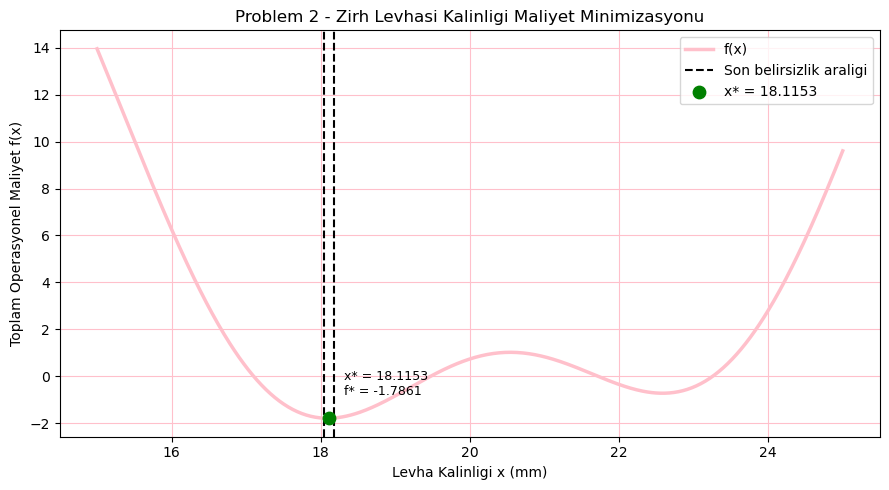

In [10]:
# --- Problem 2 Grafik ---
x_seq2 = np.linspace(15, 25, 500)
y_seq2 = f2(x_seq2)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_seq2, y_seq2, lw=2.5, color="pink", label="f(x)")
ax.axvline(a2_son, linestyle="--", color="black", lw=1.5,
           label="Son belirsizlik araligi")
ax.axvline(b2_son, linestyle="--", color="black", lw=1.5)
ax.scatter(x_opt2, f_opt2, color="green", zorder=5, s=80,
           label=f"x* = {x_opt2:.4f}")
ax.annotate(f"x* = {x_opt2:.4f}\nf* = {f_opt2:.4f}",
            xy=(x_opt2, f_opt2),
            xytext=(x_opt2 + 0.2, f_opt2 + 1),
            fontsize=9, color="black")

ax.set_xlabel("Levha Kalinligi x (mm)")
ax.set_ylabel("Toplam Operasyonel Maliyet f(x)")
ax.set_title("Problem 2 - Zirh Levhasi Kalinligi Maliyet Minimizasyonu")
ax.legend()
ax.grid(True, color="pink")
plt.tight_layout()
plt.show()

---
## Genel Degerlendirme

In [11]:
# --- Karsilastirmali Ozet Tablosu ---
ozet = pd.DataFrame({
    "Ozellik": [
        "Problem Turu", "Fonksiyon", "Aralik",
        "Epsilon", "Iterasyon Sayisi",
        "Son aralik a", "Son aralik b",
        "Optimal x*", "Optimal f(x*)"
    ],
    "Problem 1 (Max)": [
        "Maksimizasyon",
        "x*sin(x)+2*cos(0.5x)-0.1x^2+3",
        "[3, 7]",
        "0.15",
        iter1,
        round(a1_son, 4),
        round(b1_son, 4),
        round(x_opt1, 4),
        round(f_opt1, 4)
    ],
    "Problem 2 (Min)": [
        "Minimizasyon",
        "0.5*(x-20)^2+3*sin(x)+0.02x^2-x+10",
        "[15, 25]",
        "0.2",
        iter2,
        round(a2_son, 4),
        round(b2_son, 4),
        round(x_opt2, 4),
        round(f_opt2, 4)
    ]
})

display(ozet)

,Ozellik,Problem 1 (Max),Problem 2 (Min)
0,Problem Turu,Maksimizasyon,Minimizasyon
1,Fonksiyon,x*sin(x)+2*cos(0.5x)-0.1x^2+3,0.5*(x-20)^2+3*sin(x)+0.02x^2-x+10
2,Aralik,"[3, 7]","[15, 25]"
3,Epsilon,0.15,0.2
4,Iterasyon Sayisi,7,9
5,Son aralik a,3,18.0495
6,Son aralik b,3.1378,18.1811
7,Optimal x*,3.0689,18.1153
8,Optimal f(x*),2.3538,-1.7861


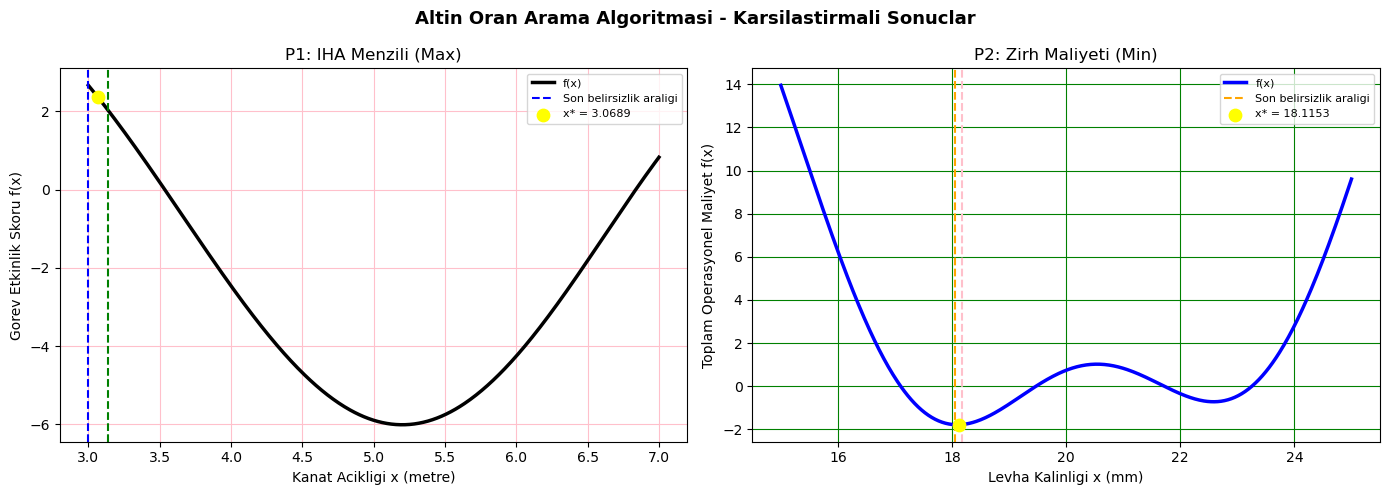

In [12]:
# --- Iki Problem Yan Yana Grafik ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Problem 1
ax1.plot(x_seq1, y_seq1, lw=2.5, color="black", label="f(x)")
ax1.axvline(a1_son, linestyle="--", color="blue", lw=1.5,
            label="Son belirsizlik araligi")
ax1.axvline(b1_son, linestyle="--", color="green", lw=1.5)
ax1.scatter(x_opt1, f_opt1, color="yellow", zorder=5, s=80,
            label=f"x* = {x_opt1:.4f}")
ax1.set_xlabel("Kanat Acikligi x (metre)")
ax1.set_ylabel("Gorev Etkinlik Skoru f(x)")
ax1.set_title("P1: IHA Menzili (Max)")
ax1.legend(fontsize=8)
ax1.grid(True, color="pink")

# Problem 2
ax2.plot(x_seq2, y_seq2, lw=2.5, color="blue", label="f(x)")
ax2.axvline(a2_son, linestyle="--", color="orange", lw=1.5,
            label="Son belirsizlik araligi")
ax2.axvline(b2_son, linestyle="--", color="pink", lw=1.5)
ax2.scatter(x_opt2, f_opt2, color="yellow", zorder=5, s=80,
            label=f"x* = {x_opt2:.4f}")
ax2.set_xlabel("Levha Kalinligi x (mm)")
ax2.set_ylabel("Toplam Operasyonel Maliyet f(x)")
ax2.set_title("P2: Zirh Maliyeti (Min)")
ax2.legend(fontsize=8)
ax2.grid(True, color="green")

plt.suptitle("Altin Oran Arama Algoritmasi - Karsilastirmali Sonuclar",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()